### Dataset 
Exploring FIN5+FIN3: length of documents, NE distribution on each document

In [1]:
from util.preprocessing import parse_iob2_file, doc_token_count
import numpy as np
import matplotlib.pyplot as plt

In [2]:
fin5_path = "data/FIN5_fixed.txt"
fin3_path = "data/FIN3_fixed.txt"
synth_path = "data/full_synth.txt"

sentences_fin5, labels_fin5 = parse_iob2_file(fin5_path)
sentences_fin3, labels_fin3 = parse_iob2_file(fin3_path)
sentences_synth, labels_synth = parse_iob2_file(synth_path)

fin5_word_len = doc_token_count(sentences_fin5)
fin3_word_len = doc_token_count(sentences_fin3)
synth_word_len = doc_token_count(sentences_synth)

fin5_mean = np.mean(fin5_word_len)
fin5_std = np.std(fin5_word_len)

fin3_mean = np.mean(fin3_word_len)
fin3_std = np.std(fin3_word_len)

synth_mean = np.mean(synth_word_len)
synth_std = np.std(synth_word_len)

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator, FuncFormatter
from matplotlib.lines import Line2D
dummy = Line2D([], [], color='none')

# =========================
# GLOBAL SETTINGS
# =========================

bar_color = "#4C72B0"
bar_width = 0.6

# shared y-axis max for comparability
max_y = max(
    max(fin5_word_len),
    max(fin3_word_len)
) * 1.1

# x labels
fin5_docs = [f"Doc{i+1}" for i in range(len(fin5_word_len))]
fin3_docs = [f"Doc{i+1}" for i in range(len(fin3_word_len))]
synth_docs = [f"Doc{i+1}" for i in range(len(synth_word_len))]

# numeric x positions
x_fin5 = np.arange(len(fin5_word_len))
x_fin3 = np.arange(len(fin3_word_len))
x_synth = np.arange(len(synth_word_len))

#### FIN5
Word count distribution per document

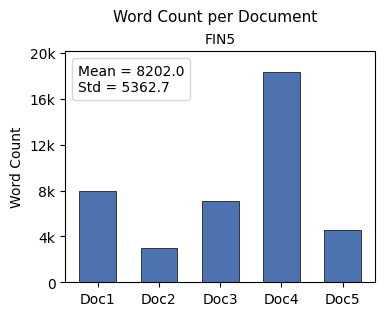

In [4]:
fig, ax = plt.subplots(figsize=(4, 3))

ax.bar(
    x_fin5,
    fin5_word_len,
    width=bar_width,
    color=bar_color,
    edgecolor="black",
    linewidth=0.5
)

ax.set_title("FIN5", fontsize=10)
ax.set_ylabel("Word Count")

ax.set_xticks(x_fin5)
ax.set_xticklabels(fin5_docs)

ax.set_ylim(0, max_y)

ax.legend(
    handles=[dummy],
    labels=[f"Mean = {fin5_mean:.1f}\nStd = {fin5_std:.1f}"],
    handlelength=0,
    handletextpad=0
)

# format y axis
ax.yaxis.set_major_locator(MaxNLocator(6))

ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda x, _: f"{int(x/1000)}k" if x >= 1000 else int(x)
    )
)

fig.suptitle(
    "Word Count per Document",
    fontsize=11,
    y=1.02
)

plt.show()

#### FIN5 NE distribution (normalized over doc length)

In [5]:
from util.preprocessing import doc_entity_count
normalized_fin5_NE = doc_entity_count(sentences_fin5, labels_fin5) / np.array(fin5_word_len)[:, np.newaxis]
normalized_fin5_NE

array([[0.01832099, 0.00288618, 0.01882294],
       [0.01528239, 0.01461794, 0.0089701 ],
       [0.00056298, 0.00408163, 0.00380014],
       [0.01898527, 0.00212766, 0.00185488],
       [0.04416884, 0.0078329 , 0.0010879 ]])

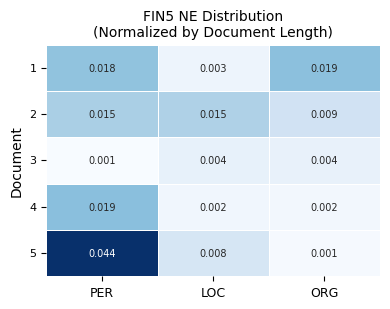

In [31]:
plt.figure(figsize=(4,3.2))

ax = sns.heatmap(
    normalized_fin5_NE,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    cbar=False,
    linewidths=0.5,
    linecolor="white",
    annot_kws={"size": 7},
    xticklabels=["PER", "LOC", "ORG"],
    yticklabels=np.arange(1, 6)
)

plt.ylabel("Document")

plt.xticks(fontsize=9)
plt.yticks(rotation=0, fontsize=8)

plt.title(
    "FIN5 NE Distribution\n(Normalized by Document Length)",
    fontsize=10
)

plt.tight_layout()
plt.show()

---
#### FIN3 word count distribution per document

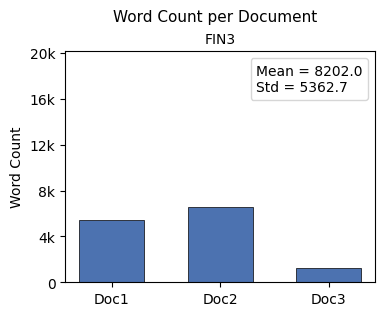

In [7]:
fig, ax = plt.subplots(figsize=(4, 3))

ax.bar(
    x_fin3,
    fin3_word_len,
    width=bar_width,
    color=bar_color,
    edgecolor="black",
    linewidth=0.5
)

ax.set_title("FIN3", fontsize=10)
ax.set_ylabel("Word Count")

ax.set_xticks(x_fin3)
ax.set_xticklabels(fin3_docs)

ax.set_ylim(0, max_y)

ax.legend(
    handles=[dummy],
    labels=[f"Mean = {fin5_mean:.1f}\nStd = {fin5_std:.1f}"],
    handlelength=0,
    handletextpad=0
)

# format y axis
ax.yaxis.set_major_locator(MaxNLocator(6))

ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda x, _: f"{int(x/1000)}k" if x >= 1000 else int(x)
    )
)

fig.suptitle(
    "Word Count per Document",
    fontsize=11,
    y=1.02
)

plt.show()

#### FIN3 NE distribution (normalized over doc length)

In [8]:
from util.preprocessing import doc_entity_count
normalized_fin3_NE = doc_entity_count(sentences_fin3, labels_fin3) / np.array(fin3_word_len)[:, np.newaxis]
normalized_fin3_NE

array([[0.02404735, 0.00425453, 0.00240474],
       [0.00967791, 0.00060487, 0.00362922],
       [0.01792991, 0.01059495, 0.01548492]])

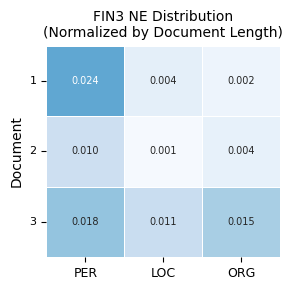

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(3,3))

ax = sns.heatmap(
    normalized_fin3_NE,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    cbar=False,
    vmin=0,
    vmax=0.045,
    linewidths=0.5,
    linecolor="white",
    annot_kws={"size": 7},
    xticklabels=["PER", "LOC", "ORG"],
    yticklabels=np.arange(1, 4)
)

plt.ylabel("Document")

plt.xticks(fontsize=9)
plt.yticks(rotation=0, fontsize=8)

plt.title(
    "FIN3 NE Distribution\n(Normalized by Document Length)",
    fontsize=10
)

plt.tight_layout()
plt.show()

---
#### Synthetic word count distribution per document

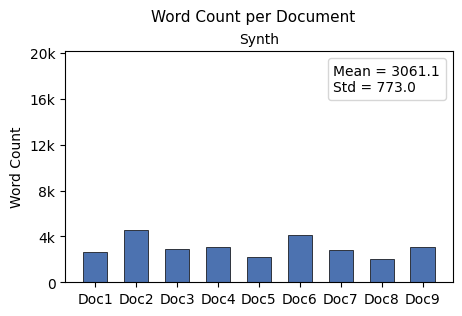

In [10]:
fig, ax = plt.subplots(figsize=(5, 3))

ax.bar(
    x_synth,
    synth_word_len,
    width=bar_width,
    color=bar_color,
    edgecolor="black",
    linewidth=0.5
)

ax.set_title("Synth", fontsize=10)
ax.set_ylabel("Word Count")

ax.set_xticks(x_synth)
ax.set_xticklabels(synth_docs)

ax.set_ylim(0, max_y)

ax.legend(
    handles=[dummy],
    labels=[f"Mean = {synth_mean:.1f}\nStd = {synth_std:.1f}"],
    handlelength=0,
    handletextpad=0
)

# format y axis
ax.yaxis.set_major_locator(MaxNLocator(6))

ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda x, _: f"{int(x/1000)}k" if x >= 1000 else int(x)
    )
)

fig.suptitle(
    "Word Count per Document",
    fontsize=11,
    y=1.02
)

plt.show()

In [11]:
normalized_synth_NE = doc_entity_count(sentences_synth, labels_synth) / np.array(synth_word_len)[:, np.newaxis]
normalized_synth_NE

array([[0.02945619, 0.02303625, 0.01397281],
       [0.02463163, 0.01495492, 0.00329888],
       [0.02972327, 0.00614964, 0.00409976],
       [0.02245363, 0.00390498, 0.00325415],
       [0.03732362, 0.01137915, 0.00637233],
       [0.03270803, 0.00649351, 0.002405  ],
       [0.0396909 , 0.01229364, 0.00561995],
       [0.02803287, 0.00869986, 0.00724988],
       [0.03631647, 0.00486381, 0.00291829]])

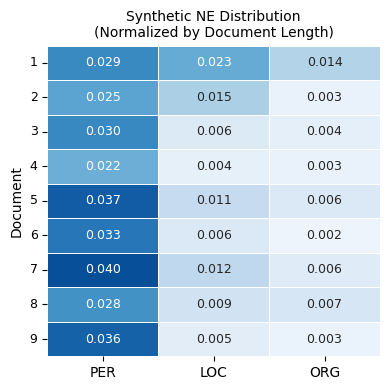

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(4,4))

ax = sns.heatmap(
    normalized_synth_NE,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    cbar=False,
    vmin=0,
    vmax=0.045,
    linewidths=0.5,
    linecolor="white",
    annot_kws={"size": 9},
    xticklabels=["PER", "LOC", "ORG"],
    yticklabels=np.arange(1, 10)
)

plt.ylabel("Document")
plt.yticks(rotation=0, fontsize=9)

plt.title("Synthetic NE Distribution\n(Normalized by Document Length)", fontsize=10)

plt.tight_layout()
plt.show()

---
### Sentence length distribution in each dataset

In [ ]:
# Function to parse IOB2 files and get sentence lengths

# Paths to files
train_path = "data/en_ewt-ud-train.iob2"


fin5_path = "data/FIN5_fixed.txt"
fin3_path = "data/FIN3_fixed.txt"
synth_path = "data/full_synth.txt"

# Parse files
sentences_ewt, _ = parse_iob2_file(train_path)
sentences_fin5, _ = parse_iob2_file(fin5_path)
sentences_fin3, _ = parse_iob2_file(fin3_path)
sentences_synth, _ = parse_iob2_file(synth_path)

# Compute lengths
lengths_ewt = [len(s) for s in sentences_ewt]
lengths_fin5 = [len(s) for s in sentences_fin5]
lengths_fin3 = [len(s) for s in sentences_fin3]
lengths_synth = [len(s) for s in sentences_synth]

print("en_ewt-ud-train.iob2:")
print(f"Mean: {np.mean(lengths_ewt):.2f}, Min: {np.min(lengths_ewt)}, Max: {np.max(lengths_ewt)}")

print("FIN5_fixed.txt:")
print(f"Mean: {np.mean(lengths_fin5):.2f}, Min: {np.min(lengths_fin5)}, Max: {np.max(lengths_fin5)}")

print("FIN3_fixed.txt:")
print(f"Mean: {np.mean(lengths_fin3):.2f}, Min: {np.min(lengths_fin3)}, Max: {np.max(lengths_fin3)}")

print(f"full_synth.txt:")
print(f"Mean: {np.mean(lengths_synth):.2f}, Min: {np.min(lengths_synth)}, Max: {np.max(lengths_synth)}")

en_ewt-ud-train.iob2:
Mean: 16.31, Min: 1, Max: 159
FIN5_fixed.txt:
Mean: 35.09, Min: 1, Max: 413
FIN3_fixed.txt:
Mean: 43.30, Min: 1, Max: 641
full_synth.txt:
Mean: 21.50, Min: 1, Max: 135


Plotting differences

C:\Users\marib\AppData\Local\Temp\ipykernel_56484\959149139.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([lengths_ewt, lengths_fin5, lengths_fin3, lengths_synth], labels=["en_ewt-ud-train", "FIN5_fixed", "FIN3_fixed", "Synth"])


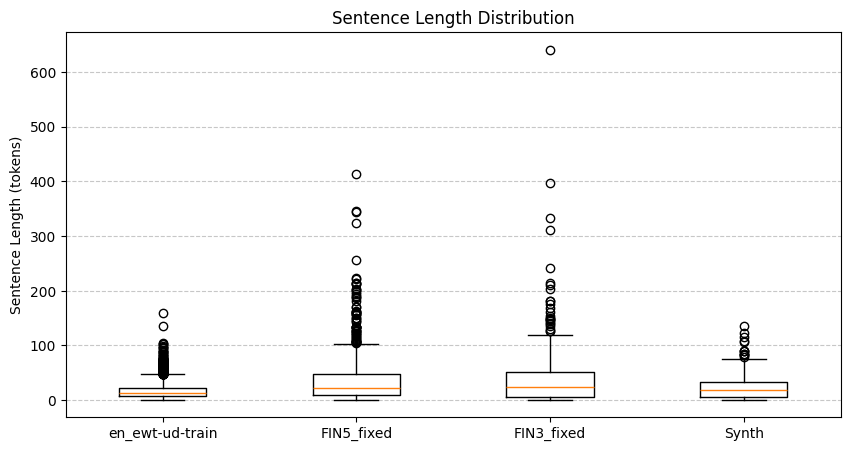

In [5]:
plt.figure(figsize=(10, 5))
plt.boxplot([lengths_ewt, lengths_fin5, lengths_fin3, lengths_synth], labels=["en_ewt-ud-train", "FIN5_fixed", "FIN3_fixed", "Synth"])
plt.ylabel("Sentence Length (tokens)")
plt.title("Sentence Length Distribution")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()